# AOMIC-ID1000 - Brain Preprocessing and Visualisation

Two brain modalities feed the highest complexity tiers, kept as separate ontology
domains:

* **Morphometry (FreeSurfer)** - subcortical volumes, cortical thickness by lobe, and
  global brain measures, parsed from the per-subject stats tables.
* **Connectome (movie-watching fMRI)** - Schaefer-100 / Yeo-7 parcellation reduced to
  network-level functional connectivity.

This notebook visualises both and their relationship to intelligence.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting, datasets
sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().parent
part = pd.read_csv(ROOT / "dataset" / "participants.tsv", sep="\t", na_values=["n/a",""])
target = pd.to_numeric(part.set_index("participant_id")["IST_intelligence_total"], errors="coerce")
morph = pd.read_csv(ROOT / "brain" / "freesurfer" / "morphometry_features.csv", index_col=0)
print("morphometry:", morph.shape, "| connectome subjects available:",
      len(list((ROOT / "brain" / "connectome" / "network_fc").glob("*.npy"))))

morphometry: (120, 35) | connectome subjects available: 23


## FreeSurfer morphometry: subcortical volumes

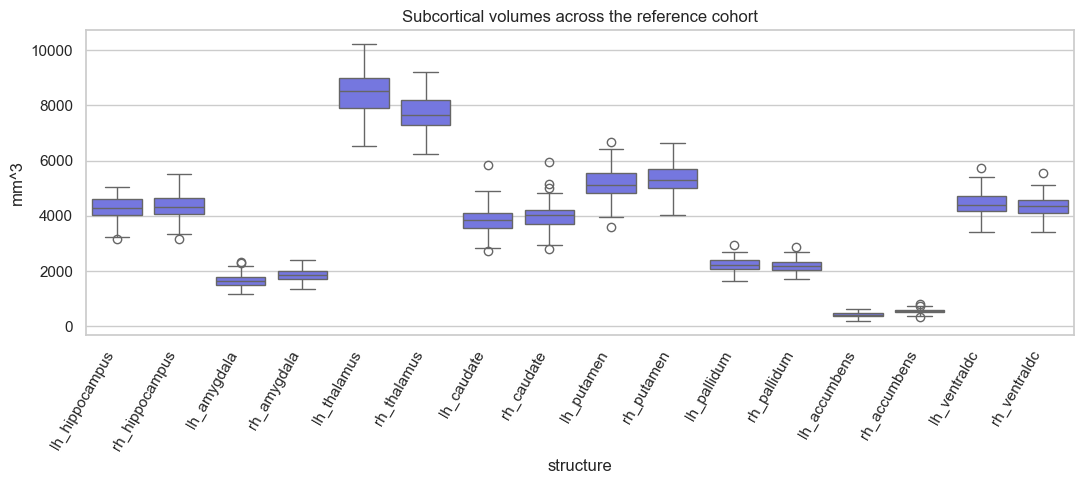

In [2]:
sub_cols = [c for c in morph.columns if c.startswith("fs_vol_")]
melt = morph[sub_cols].melt(var_name="structure", value_name="volume")
melt["structure"] = melt["structure"].str.replace("fs_vol_","",regex=False)
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=melt, x="structure", y="volume", ax=ax, color="#6366f1")
ax.set(title="Subcortical volumes across the reference cohort", ylabel="mm^3")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()

## Morphometry correlation structure and link to intelligence

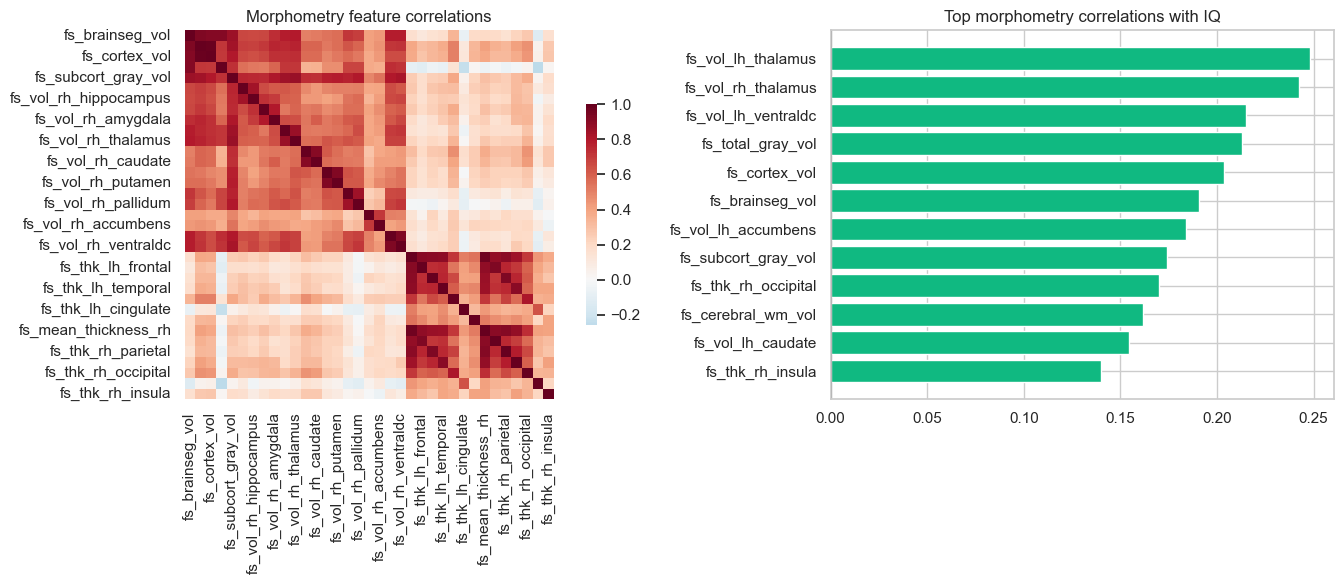

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios":[1.3,1]})
sns.heatmap(morph.corr(), cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":.6}, ax=ax[0])
ax[0].set_title("Morphometry feature correlations")
rows = []
for c in morph.columns:
    m = morph[c].notna() & target.reindex(morph.index).notna()
    if m.sum() > 30:
        rows.append((c, float(np.corrcoef(morph[c][m], target.reindex(morph.index)[m])[0,1])))
rho = pd.DataFrame(rows, columns=["feature","r"]).sort_values("r").tail(12)
ax[1].barh(rho["feature"], rho["r"], color=["#ef4444" if v<0 else "#10b981" for v in rho["r"]])
ax[1].axvline(0, color="#333"); ax[1].set_title("Top morphometry correlations with IQ")
plt.tight_layout(); plt.show()

Global volume measures (intracranial and gray-matter volume) carry the familiar weak
positive brain-size / intelligence association. Individual regions are noisier at this
sample size, which is why morphometry enters as its own tier to see its marginal value.

## Functional connectome: network-level FC matrix

<Figure size 650x550 with 0 Axes>

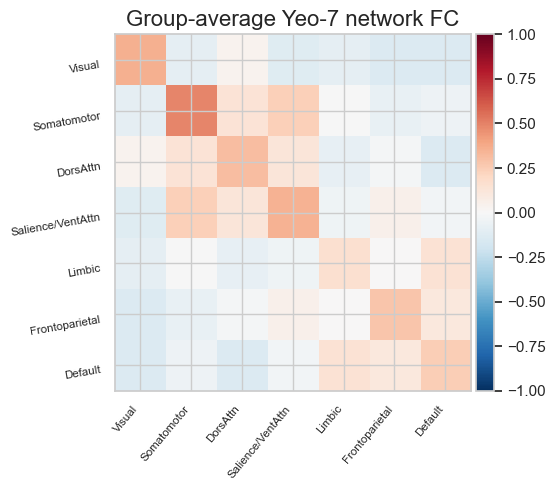

In [4]:
YEO7 = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
LBL = ["Visual","Somatomotor","DorsAttn","Salience/VentAttn","Limbic","Frontoparietal","Default"]
fc_dir = ROOT / "brain" / "connectome" / "network_fc"
mats = np.stack([np.load(p) for p in sorted(fc_dir.glob("*.npy"))])
group_fc = np.nanmean(mats, axis=0)
fig = plt.figure(figsize=(6.5, 5.5))
plotting.plot_matrix(group_fc, labels=LBL, colorbar=True, vmin=-1, vmax=1,
                     title="Group-average Yeo-7 network FC", reorder=False)
plt.show()

This 7x7 matrix is the reduced connectome the engine sees: 7 within-network and 21
between-network mean correlations (28 features). Reducing ~5000 parcel edges to 28
interpretable, network-labelled features is what makes the connectome usable by an
LLM-reasoning engine without losing the meaning of each value.

## Glass-brain connectome (one subject, parcel level)

[get_dataset_dir] Dataset found in /Users/stijnvanseveren/nilearn_data/schaefer_2018

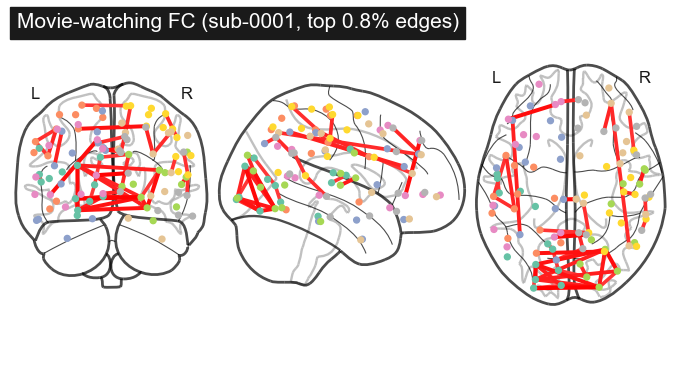

In [5]:
# Recompute one subject's parcel-level FC to visualise the full network on a glass brain.
repo_root = next(p for p in [ROOT, *ROOT.parents] if (p / "src" / "full_stack").is_dir())
sys.path.insert(0, str(repo_root))  # for validation.common
from validation.common import connectome as conn
sub = sorted(p.stem for p in fc_dir.glob("*.npy"))[0]
atlas = conn.load_atlas(100, 7, 2)
coords = plotting.find_parcellation_cut_coords(atlas.maps)
paths = conn.download_func(sub, "ds003097", ROOT / "brain" / "_cache" / "connectome")
ts = conn.parcel_timeseries(paths, atlas)
parcel_fc = np.corrcoef(ts.T)
plotting.plot_connectome(parcel_fc, coords, edge_threshold="99.2%", node_size=18,
                         title=f"Movie-watching FC ({sub}, top 0.8% edges)")
plt.show()
for k in ("bold","mask"):
    p = paths.get(k)
    if p and Path(p).exists(): Path(p).unlink()  # tidy the large download

The glass brain shows the strongest parcel-to-parcel connections for one participant,
computed by the exact same pipeline used for feature extraction. The committed engine
features are the network-level summary above; this full view is for inspection only.